In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

Usando device: cpu



--- Carregando Dataset de Phishing ---
Shape original dos dados: (235795, 54)
Shape do target: (235795,)


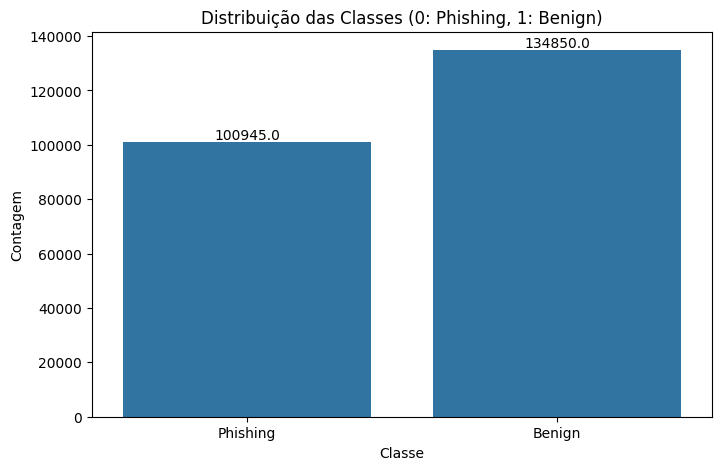

In [43]:

# Import do dataset de phishing
print("\n--- Carregando Dataset de Phishing ---")
phishing_dataset = fetch_ucirepo(id=967) 
X_df = phishing_dataset.data.features 
y_df = phishing_dataset.data.targets
y = y_df.iloc[:, 0].astype('category').cat.codes.values

print(f"Shape original dos dados: {X_df.shape}")
print(f"Shape do target: {y.shape}")

# Visualização da distribuição das classes
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y)
plt.title('Distribuição das Classes (0: Phishing, 1: Benign)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1], labels=['Phishing', 'Benign'])

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

In [44]:
# Pré-processamento dos dados

print("\n--- Pré-processando os Dados ---")
# Identificar e selecionar apenas as colunas numéricas
numeric_features = X_df.select_dtypes(include=np.number).columns.tolist()
X_numeric = X_df[numeric_features]
print(f"Usando {X_numeric.shape[1]} features numéricas.")
print(f"Removidas {X_df.shape[1] - X_numeric.shape[1]} features não-numéricas.")

# Normalizar os dados numéricos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
print("Dados numéricos normalizados com StandardScaler.")


--- Pré-processando os Dados ---
Usando 50 features numéricas.
Removidas 4 features não-numéricas.
Dados numéricos normalizados com StandardScaler.


In [45]:
# Dividir os dados em treino, validação e teste
# 60% para treino, 20% para validação e 20% para teste,

print("\n--- Dividindo os Dados em Treino, Validação e Teste ---")
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

# Converter para Tensors do PyTorch
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)


--- Dividindo os Dados em Treino, Validação e Teste ---
Treino: 141477 amostras
Validação: 47159 amostras
Teste: 47159 amostras


In [ ]:
# Arquitetura da Rede Neural
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Parâmetros do modelo
input_size = X_scaled.shape[1]
hidden_size = 64
num_classes = 2
learning_rate = 0.001
num_epochs = 200

# Instanciar modelo, critério e otimizador
model = MLP(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
print(f"\nModelo criado com arquitetura: {input_size} -> {hidden_size} -> {hidden_size} -> {num_classes}")



Modelo criado com arquitetura: 50 -> 64 -> 64 -> 2


In [47]:
print("\n--- Iniciando Treinamento ---")
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

def calculate_accuracy(outputs, targets):
    _, predicted = torch.max(outputs.data, 1)
    total = targets.size(0)
    correct = (predicted == targets).sum().item()
    return 100 * correct / total

for epoch in range(num_epochs):
    model.train()
    train_outputs = model(X_train_tensor)
    train_loss = criterion(train_outputs, y_train_tensor)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        train_acc = calculate_accuracy(train_outputs, y_train_tensor)
        val_acc = calculate_accuracy(val_outputs, y_val_tensor)
        
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Val Acc: {val_acc:.2f}%')

print("Treinamento concluído!")



--- Iniciando Treinamento ---
Epoch [20/200], Train Loss: 0.3115, Val Acc: 98.66%
Epoch [40/200], Train Loss: 0.0560, Val Acc: 99.14%
Epoch [60/200], Train Loss: 0.0200, Val Acc: 99.55%
Epoch [80/200], Train Loss: 0.0115, Val Acc: 99.75%
Epoch [100/200], Train Loss: 0.0078, Val Acc: 99.85%
Epoch [120/200], Train Loss: 0.0058, Val Acc: 99.90%
Epoch [140/200], Train Loss: 0.0045, Val Acc: 99.92%
Epoch [160/200], Train Loss: 0.0036, Val Acc: 99.94%
Epoch [180/200], Train Loss: 0.0030, Val Acc: 99.95%
Epoch [200/200], Train Loss: 0.0025, Val Acc: 99.95%
Treinamento concluído!


In [48]:
print("\n--- Avaliando o Modelo no Conjunto de Teste ---")
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    test_acc = calculate_accuracy(test_outputs, y_test_tensor)
    _, predicted = torch.max(test_outputs.data, 1)
    
print(f'Acurácia no conjunto de teste: {test_acc:.2f}%')
print(f'Loss no conjunto de teste: {test_loss.item():.4f}')



--- Avaliando o Modelo no Conjunto de Teste ---
Acurácia no conjunto de teste: 99.95%
Loss no conjunto de teste: 0.0025


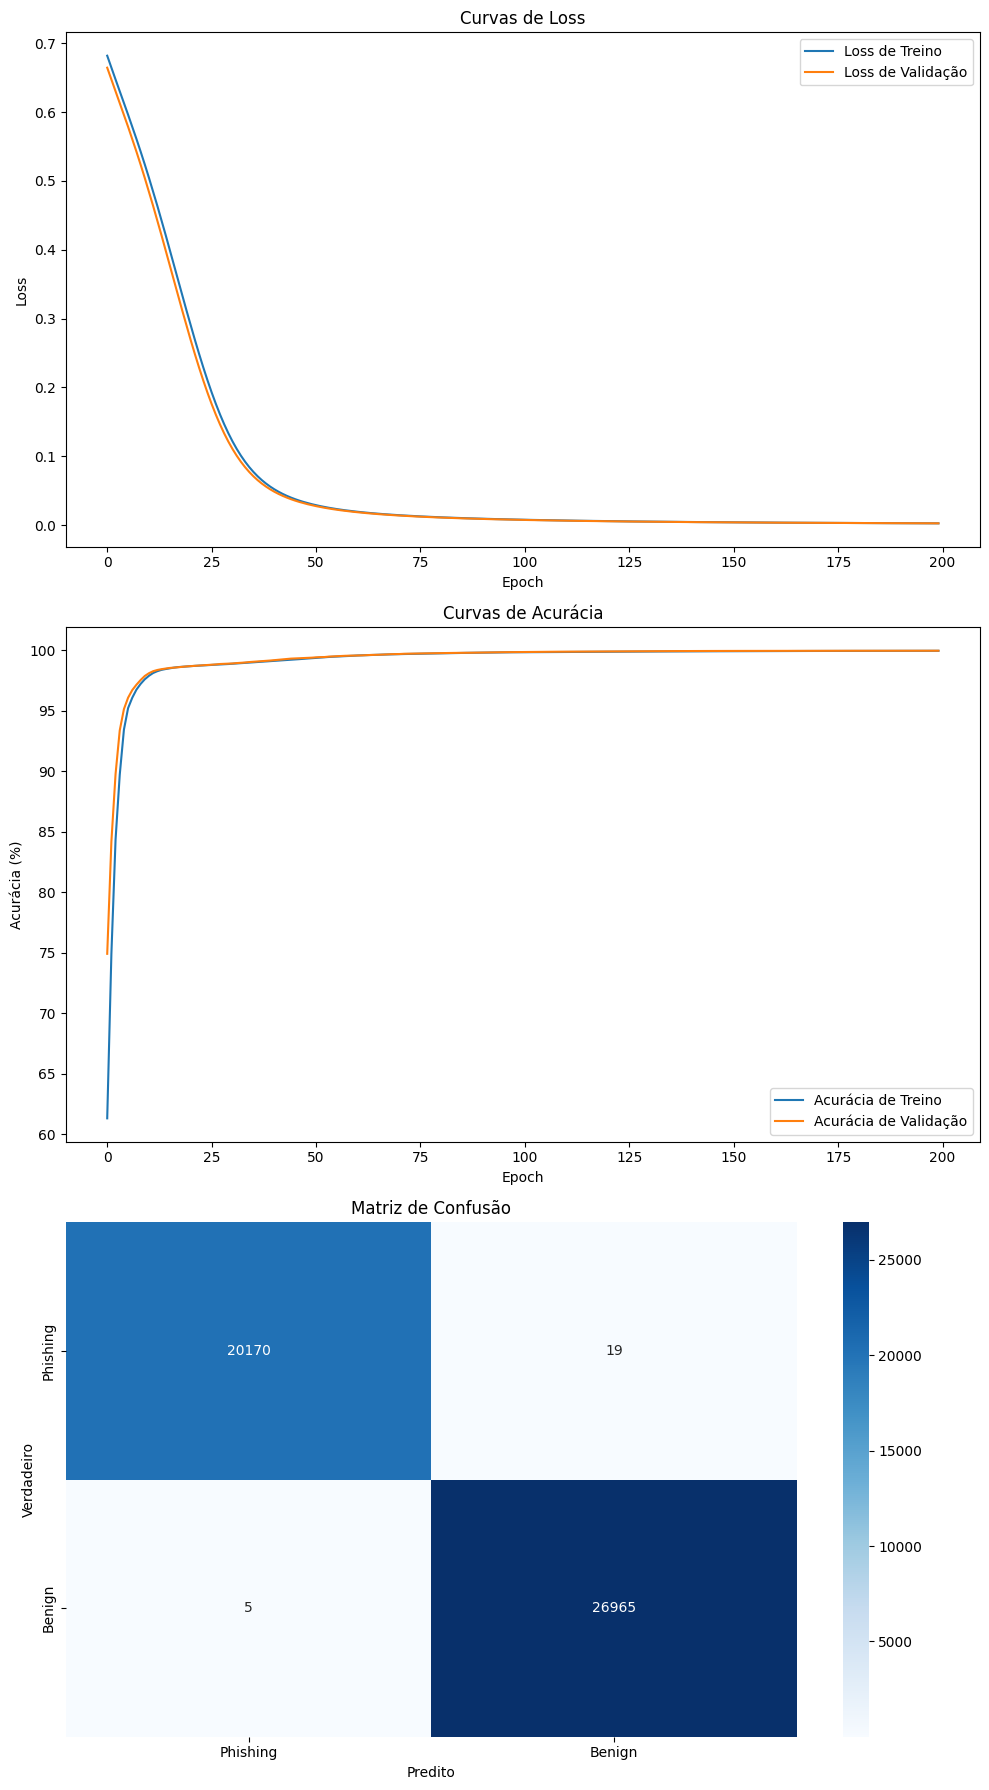


Relatório de Classificação:
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
      Benign       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



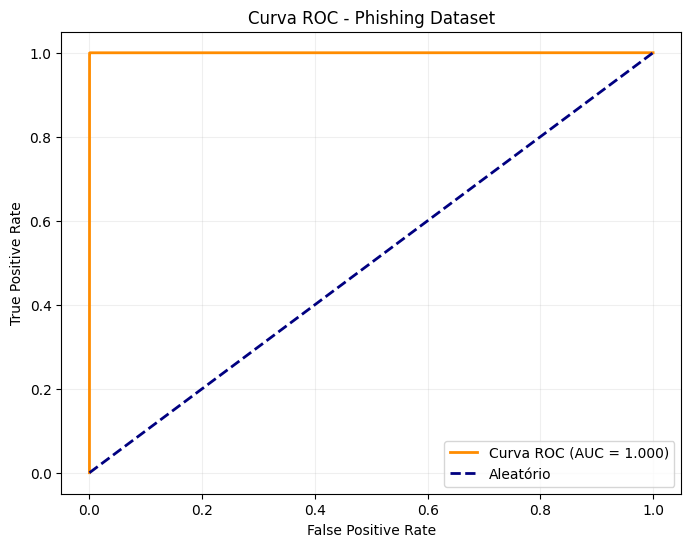

AUC Score: 1.0000


In [49]:

# 9. Visualização dos Resultados
# Curvas de Aprendizado
plt.figure(figsize=(10, 18))

plt.subplot(3, 1, 1) 
plt.plot(train_losses, label='Loss de Treino')
plt.plot(val_losses, label='Loss de Validação')
plt.title('Curvas de Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(3, 1, 2) 
plt.plot(train_accuracies, label='Acurácia de Treino')
plt.plot(val_accuracies, label='Acurácia de Validação')
plt.title('Curvas de Acurácia')
plt.xlabel('Epoch')
plt.ylabel('Acurácia (%)')
plt.legend()

y_pred_np = predicted.cpu().numpy()
y_true_np = y_test

plt.subplot(3, 1, 3) 
cm = confusion_matrix(y_true_np, y_pred_np)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Benign'], yticklabels=['Phishing', 'Benign'])
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')

plt.tight_layout()
plt.show()

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true_np, y_pred_np, target_names=['Phishing', 'Benign']))

# Curva ROC e AUC
with torch.no_grad():
    y_score = torch.softmax(test_outputs, dim=1)[:, 1].cpu().numpy()

fpr, tpr, _ = roc_curve(y_true_np, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Phishing Dataset')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

In [ ]:

print("\n--- Salvando o Modelo ---")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler': scaler,
    'model_params': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_classes': num_classes
    },
    'numeric_features': numeric_features # Salvar as colunas usadas
}, 'phishing_mlp_model.pth')

print("Modelo salvo como 'phishing_mlp_model.pth'")


--- Salvando o Modelo ---
Modelo salvo como 'phishing_mlp_model.pth'
